In [29]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

In [106]:
BATCH_SIZE = 16
IMAGE_SIZE = 128
CHANNELS=3
EPOCHS=50

In [107]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)


Found 16011 files belonging to 10 classes.


In [108]:
class_names = dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [109]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(16, 128, 128, 3)
[7 2 4 6 5 7 6 5 6 7 4 7 1 1 2 1]


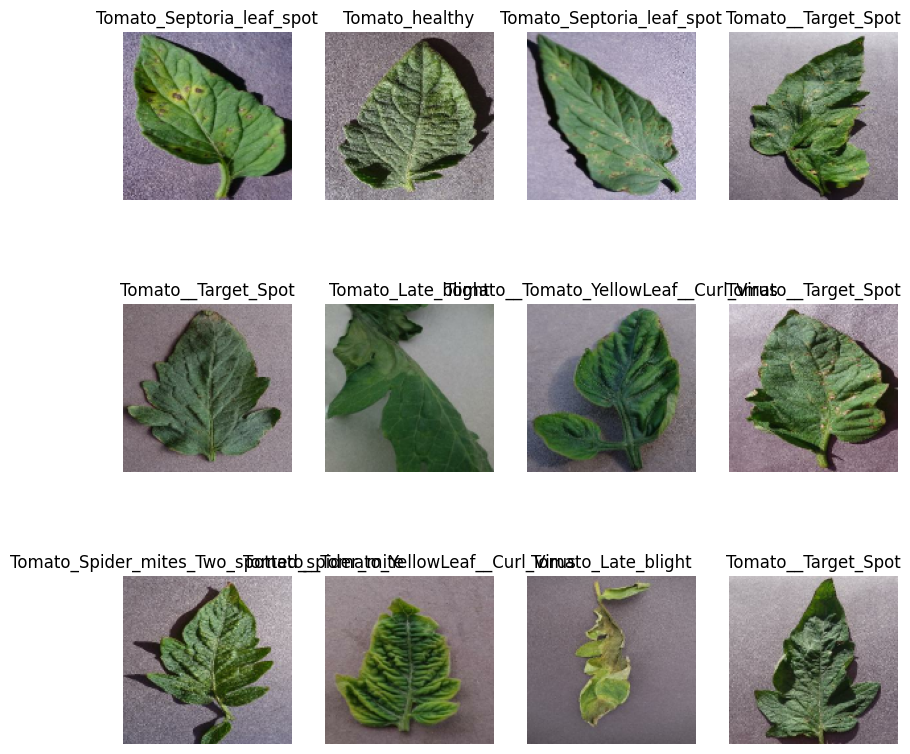

In [110]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [111]:
len(dataset)

1001

In [112]:
train_size = 0.8
len(dataset)*train_size

800.8000000000001

In [113]:
train_ds = dataset.take(54)
len(train_ds)

54

In [114]:
test_ds = dataset.skip(54)
len(test_ds)

947

In [115]:
val_size=0.1
len(dataset)*val_size

100.10000000000001

In [116]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [117]:
test_ds = test_ds.skip(6)
len(test_ds)

941

In [118]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [119]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)


In [120]:
len(train_ds)

800

In [121]:
len(val_ds)

100

In [122]:
len(test_ds)

101

In [123]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [124]:
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.experimental.preprocessing.Rescaling(1./255),
])

In [125]:
data_augmentation = tf.keras.Sequential([
  layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  layers.experimental.preprocessing.RandomRotation(0.2),
   layers.experimental.preprocessing.RandomZoom(0.2),
   layers.experimental.preprocessing.RandomContrast(0.2),  
])

In [126]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [129]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 10

model = models.Sequential([
    resize_and_rescale,

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(n_classes, activation='softmax')
])

model.build(input_shape=input_shape)


In [130]:
model.summary()

Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_16 (Sequential)  (16, 128, 128, 3)         0         
                                                                 
 conv2d_69 (Conv2D)          (16, 128, 128, 32)        896       
                                                                 
 batch_normalization_41 (Bat  (16, 128, 128, 32)       128       
 chNormalization)                                                
                                                                 
 max_pooling2d_69 (MaxPoolin  (16, 64, 64, 32)         0         
 g2D)                                                            
                                                                 
 conv2d_70 (Conv2D)          (16, 64, 64, 64)          18496     
                                                                 
 batch_normalization_42 (Bat  (16, 64, 64, 64)       

In [131]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [132]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
800/800 [==============================] - 94s 103ms/step - loss: 1.0711 - accuracy: 0.6337 - val_loss: 2.3344 - val_accuracy: 0.4006
Epoch 2/50
800/800 [==============================] - 72s 91ms/step - loss: 0.6824 - accuracy: 0.7637 - val_loss: 3.4378 - val_accuracy: 0.3706
Epoch 3/50
800/800 [==============================] - 66s 82ms/step - loss: 0.5166 - accuracy: 0.8199 - val_loss: 1.3183 - val_accuracy: 0.6931
Epoch 4/50
800/800 [==============================] - 60s 74ms/step - loss: 0.4129 - accuracy: 0.8546 - val_loss: 0.5718 - val_accuracy: 0.8156
Epoch 5/50
800/800 [==============================] - 60s 76ms/step - loss: 0.3546 - accuracy: 0.8784 - val_loss: 1.3966 - val_accuracy: 0.6712
Epoch 6/50
800/800 [==============================] - 60s 75ms/step - loss: 0.3041 - accuracy: 0.8951 - val_loss: 5.2822 - val_accuracy: 0.3956
Epoch 7/50
800/800 [==============================] - 59s 74ms/step - loss: 0.2476 - accuracy: 0.9143 - val_loss: 2.3792 - val_accuracy

In [133]:
scores = model.evaluate(test_ds)

101/101 [==============================] - 8s 12ms/step - loss: 0.0488 - accuracy: 0.9821


In [134]:
scores

[0.04883940890431404, 0.9820544719696045]

In [135]:
history

In [136]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 800}

In [137]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [138]:
type(history.history['loss'])

list

In [139]:
len(history.history['loss'])

41

In [141]:
history.history['loss'][:5]  # show loss for first 5 epochs

[1.071090817451477,
 0.682405948638916,
 0.5165711641311646,
 0.4129258990287781,
 0.35461193323135376]

In [147]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']



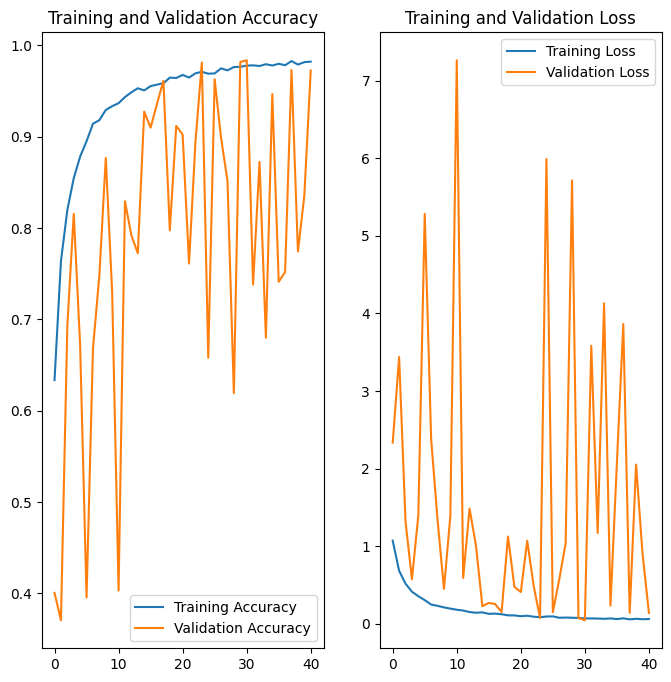

In [148]:
epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

first image to predict
actual label: Tomato_Septoria_leaf_spot
1/1 [==============================] - 0s 291ms/step
predicted label: Tomato_Septoria_leaf_spot


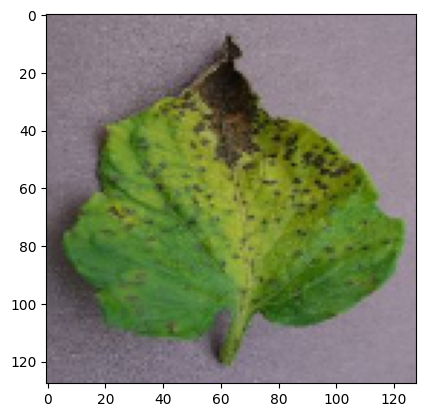

In [149]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [150]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 34ms/step


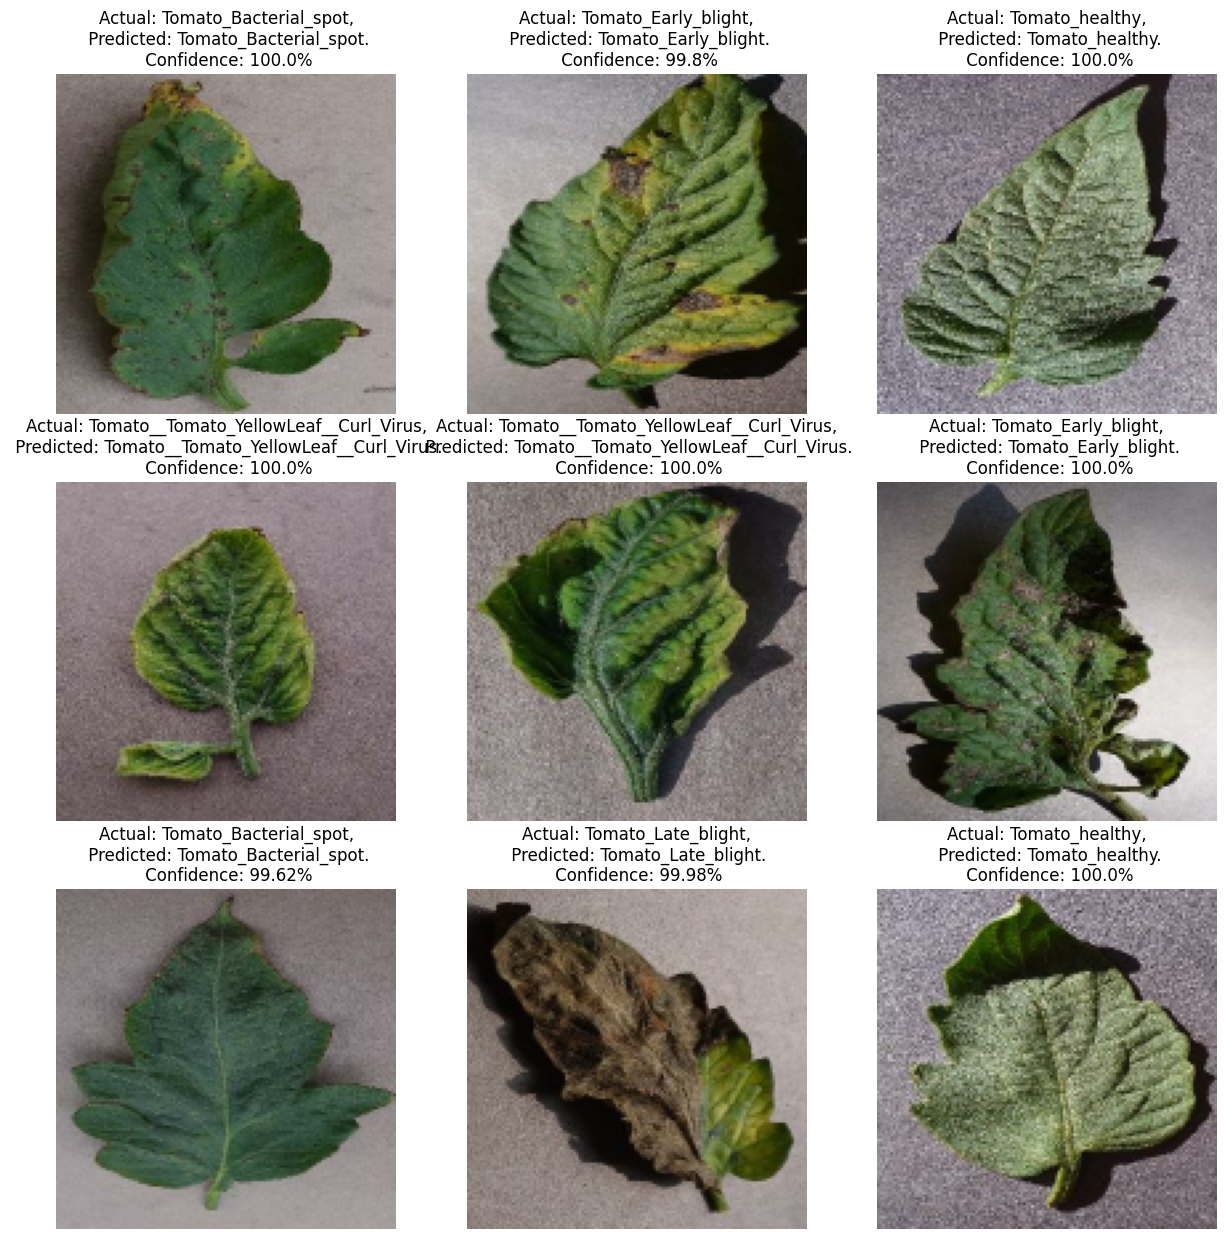

In [152]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [153]:
loss, keras_acc = model.evaluate(test_ds)

print("Keras Accuracy:", keras_acc * 100, "%")

101/101 [==============================] - 1s 12ms/step - loss: 0.0488 - accuracy: 0.9821
Keras Accuracy: 98.20544719696045 %


In [155]:
model.save("../tomato_leaf_disease_model.keras")

In [162]:
loss, acc = model.evaluate(test_ds)
print(acc)

101/101 [==============================] - 3s 29ms/step - loss: 0.0488 - accuracy: 0.9821
0.9820544719696045
